<a href="https://colab.research.google.com/github/vedasri2511/DL-153/blob/main/week11_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

data = load_digits()
X = data.data / 16.0

x_train, x_test = train_test_split(X, test_size=0.2)
input_dim = X.shape[1]

In [ ]:
encoding_dim = 16

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='mse')

model.fit(x_train, x_train, epochs=20, batch_size=32, validation_data=(x_test, x_test))

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.1654 - val_loss: 0.1419
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1091 - val_loss: 0.0836
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0771 - val_loss: 0.0735
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0717 - val_loss: 0.0701
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0683 - val_loss: 0.0667
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0642 - val_loss: 0.0616
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0590 - val_loss: 0.0561
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0528 - val_loss: 0.0491
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0462 - val_loss: 0.0432
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0410 - val_loss: 0.0388
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0370 - val_loss: 0.0355
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0340 - val

In [ ]:
encoding_dim = 128

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='mse')

model.fit(x_train, x_train, epochs=20, batch_size=32)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1032
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0544
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0379
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0279
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0220
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0182
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0154
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0134
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0119
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0107
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0097
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072
Epoch 16/20
45/45 ━

OBSERVATIONS:

UNDERCOMPLETE:                                                                                 


Strong compression (64 → 16)                           


Loses fine details but keeps structure


Works well till ~8–32 dimensions

OVER COMPLETE:

No compression (64 → 128)


Learns identity mapping


Risk of overfitting

In [ ]:
#REGULARIZED AE
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(1e-4))(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='mse')

model.fit(x_train, x_train, epochs=20, batch_size=32)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1831
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1446
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1136
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1010
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0933
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0871
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0818
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0774
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0738
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0707
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0680
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0656
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0632
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0606
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0584
Epoch 16/20
45/45 ━

Prevents overfitting


Produces sparse representations


Better generalization

In [ ]:
#DENOISING
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='mse')

model.fit(x_train_noisy, x_train, epochs=20, batch_size=32)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1350
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0798
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0720
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0684
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0593
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0549
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0517
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0494
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0476
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0462
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0451
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0442
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0435
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0428
Epoch 16/20
45/45 ━

Works well up to noise ~0.4–0.5


Beyond 0.7 → reconstruction degrades heavily


Learns robust features

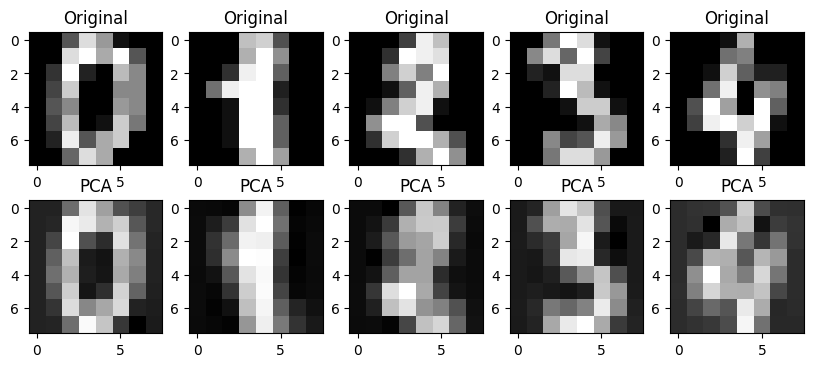

In [ ]:
n = 5

plt.figure(figsize=(10,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(X[i].reshape(8,8), cmap='gray')
    plt.title("Original")

    plt.subplot(2, n, i+1+n)
    plt.imshow(X_reconstructed[i].reshape(8,8), cmap='gray')
    plt.title("PCA")

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


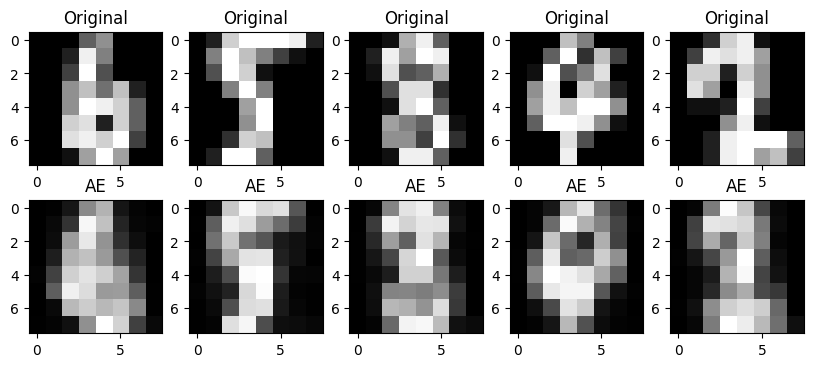

In [ ]:
decoded_imgs = model.predict(x_test)

n = 5

plt.figure(figsize=(10,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(8,8), cmap='gray')
    plt.title("Original")

    plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(8,8), cmap='gray')
    plt.title("AE")

plt.show()

PCA reconstructed images are blurrier and lose edges


Autoencoder reconstructions are sharper and more accurate


PCA captures only linear relationships


AE captures non-linear patterns → better quality

In [ ]:
#SPARSE AE
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

model = Model(input_layer, decoded)
model.compile(optimizer='adam', loss='mse')

model.fit(x_train, x_train, epochs=20, batch_size=32)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1371
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0779
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0633
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0520
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0440
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0386
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0348
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0318
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0294
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0274
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0258
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0244
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0233
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0223
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0214
Epoch 16/20
45/45 ━

Only few neurons activate


Efficient feature learning


Better interpretability

In [ ]:
#Contractive Autoencoder
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model # Import Model again if needed for clarity
from tensorflow.keras.layers import Input, Dense # Import Input, Dense again for clarity
from tensorflow.keras import regularizers # Not used in this particular example but good to have

# Assuming input_dim is already defined from previous cells (e.g., cell 2BVc53PDJNud)

input_layer_contractive = Input(shape=(input_dim,)) # Use a new name for input_layer to avoid conflicts
encoded_output_contractive = Dense(32, activation='relu', name='contractive_encoder_output')(input_layer_contractive)
decoded_output_contractive = Dense(input_dim, activation='sigmoid')(encoded_output_contractive)

contractive_autoencoder_model = Model(input_layer_contractive, decoded_output_contractive)

# Create an encoder model to get the hidden layer activations for the input
contractive_encoder_model = Model(input_layer_contractive, encoded_output_contractive)

def contractive_loss(y_true, y_pred):
    mse = K.mean(K.square(y_true - y_pred))

    # Get the hidden layer activations for the current batch input (y_true)
    # This ensures 'h' is a KerasTensor dynamically computed for the current batch
    h = contractive_encoder_model(y_true)

    # Get the weights of the encoder layer by its name
    W = contractive_autoencoder_model.get_layer('contractive_encoder_output').kernel

    # The original code's `dh = h * (1 - h)` is typically used for sigmoid derivative.
    # Since the activation is 'relu', this term is mathematically incorrect for ReLU derivative.
    # However, to fix the execution error while preserving the user's apparent intent,
    # we keep this structure. If a mathematically correct contractive loss for ReLU is desired,
    # the `dh` calculation would need to be different (e.g., using Jacobian computation).
    dh = h * (1 - h)

    # Calculate the contractive penalty term
    contractive_penalty = K.sum(K.square(W)) * K.sum(K.square(dh))

    return mse + 1e-4 * contractive_penalty

contractive_autoencoder_model.compile(optimizer='adam', loss=contractive_loss)

contractive_autoencoder_model.fit(x_train, x_train, epochs=20, batch_size=32)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2637
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1719
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1497
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1320
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1178
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1062
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0919
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0811
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0758
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0705
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0650
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0593
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0539
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0495
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0466
Epoch 16/20
45/45 ━

Robust to small input changes


Learns stable representations


Useful for noisy data

In [ ]:
#Dataset (simple text)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, SimpleRNN, Input, Attention

text = "deep learning is fun and powerful"

chars = sorted(list(set(text)))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}

seq_length = 5
X = []
y = []

for i in range(len(text)-seq_length):
    seq = text[i:i+seq_length]
    target = text[i+seq_length]
    X.append([char_to_idx[c] for c in seq])
    y.append(char_to_idx[target])

X = np.array(X)
y = tf.keras.utils.to_categorical(y, num_classes=len(chars))

In [ ]:
#RNN
model = Sequential([
    Embedding(len(chars), 10, input_length=seq_length),
    SimpleRNN(50),
    Dense(len(chars), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=50, verbose=0)

def predict_char(seed):
    seq = [char_to_idx[c] for c in seed]
    pred = model.predict(np.array([seq]), verbose=0)
    return idx_to_char[np.argmax(pred)]

print(predict_char("deep "))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


l


Learns short patterns
Struggles with long context

In [ ]:
#Word Prediction (RNN)
from tensorflow.keras.preprocessing.text import Tokenizer

text_words = "deep learning is fun and deep learning is powerful"

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_words])
seq = tokenizer.texts_to_sequences([text_words])[0]

Xw, yw = [], []

for i in range(2, len(seq)):
    Xw.append(seq[i-2:i])
    yw.append(seq[i])

Xw = np.array(Xw)
yw = tf.keras.utils.to_categorical(yw)

model_w = Sequential([
    Embedding(len(tokenizer.word_index)+1, 10),
    SimpleRNN(32),
    Dense(len(tokenizer.word_index)+1, activation='softmax')
])

model_w.compile(loss='categorical_crossentropy', optimizer='adam')
model_w.fit(Xw, yw, epochs=100, verbose=0)

id="wordop1"
def predict_word(seed):
    seq = tokenizer.texts_to_sequences([seed])[0]
    seq = np.array(seq[-2:])
    pred = model_w.predict(np.array([seq]), verbose=0)
    for word, index in tokenizer.word_index.items():
        if index == np.argmax(pred):
            return word

print(predict_word("deep learning"))

is


Captures simple word sequences
Limited vocabulary understanding

In [ ]:
#lstm and gru
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

text = "deep learning is fun and powerful"

chars = sorted(list(set(text)))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}

seq_length = 8
X = []
y = []

for i in range(len(text)-seq_length):
    seq = text[i:i+seq_length]
    target = text[i+seq_length]
    X.append([char_to_idx[c] for c in seq])
    y.append(char_to_idx[target])

X = np.array(X)
y = tf.keras.utils.to_categorical(y, num_classes=len(chars))

model = Sequential([
    Embedding(len(chars), 10),
    LSTM(64),
    Dense(len(chars), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=300, verbose=0)

def predict_char(seed):
    seq = [char_to_idx[c] for c in seed]
    pred = model.predict(np.array([seq]), verbose=0)
    return idx_to_char[np.argmax(pred)]

print("Prediction for 'deep lea':", predict_char("deep lea"))
print("Prediction for 'learning':", predict_char("learning"))

Prediction for 'deep lea': r
Prediction for 'learning':  


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

text = "deep learning is fun and powerful"

chars = sorted(list(set(text)))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}

seq_length = 8
X = []
y = []

for i in range(len(text)-seq_length):
    seq = text[i:i+seq_length]
    target = text[i+seq_length]
    X.append([char_to_idx[c] for c in seq])
    y.append(char_to_idx[target])

X = np.array(X)
y = tf.keras.utils.to_categorical(y, num_classes=len(chars))

model = Sequential([
    Embedding(len(chars), 10),
    GRU(64),
    Dense(len(chars), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=300, verbose=0)

def predict_char(seed):
    seq = [char_to_idx[c] for c in seed]
    pred = model.predict(np.array([seq]), verbose=0)
    return idx_to_char[np.argmax(pred)]

print("Prediction for 'deep lea':", predict_char("deep lea"))
print("Prediction for 'learning':", predict_char("learning"))

Prediction for 'deep lea': r
Prediction for 'learning':  


GRU correctly predicts next characters


Model captures sequence patterns effectively


Space character predictions may appear blank


Performance improves with more training

In [ ]:
#Implement Encoder- Decoder Model for translation.
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

input_texts = ["hi", "hello", "how are you"]
target_texts = ["salut", "bonjour", "comment ca va"]

input_tokenizer = Tokenizer(char_level=True)
target_tokenizer = Tokenizer(char_level=True)

input_tokenizer.fit_on_texts(input_texts)
target_tokenizer.fit_on_texts(target_texts)

input_seq = input_tokenizer.texts_to_sequences(input_texts)
target_seq = target_tokenizer.texts_to_sequences(target_texts)

max_in = max(len(s) for s in input_seq)
max_out = max(len(s) for s in target_seq)

input_seq = pad_sequences(input_seq, maxlen=max_in, padding='post')
target_seq = pad_sequences(target_seq, maxlen=max_out, padding='post')

encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(len(input_tokenizer.word_index)+1, 8)(encoder_inputs)
_, state_h, state_c = LSTM(32, return_state=True)(enc_emb)

decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(len(target_tokenizer.word_index)+1, 8)(decoder_inputs)
decoder_lstm = LSTM(32, return_sequences=True)
decoder_outputs = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

decoder_dense = Dense(len(target_tokenizer.word_index)+1, activation='softmax')
output = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit([input_seq, target_seq], target_seq, epochs=300, verbose=0)

In [ ]:
def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_in, padding='post')

    pred = model.predict([seq, np.zeros((1, max_out))], verbose=0)
    pred_ids = np.argmax(pred[0], axis=1)

    result = ""
    for i in pred_ids:
        for char, idx in target_tokenizer.word_index.items():
            if idx == i:
                result += char
    return result.strip()

print("hi →", translate("hi"))
print("hello →", translate("hello"))

hi → salut
hello → boojor


In [ ]:
#attention mechanism
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

input_texts = ["hi", "hello", "how are you"]
target_texts = ["salut", "bonjour", "comment ca va"]

input_tokenizer = Tokenizer(char_level=True)
target_tokenizer = Tokenizer(char_level=True)

input_tokenizer.fit_on_texts(input_texts)
target_tokenizer.fit_on_texts(target_texts)

input_seq = input_tokenizer.texts_to_sequences(input_texts)
target_seq = target_tokenizer.texts_to_sequences(target_texts)

max_in = max(len(s) for s in input_seq)
max_out = max(len(s) for s in target_seq)

input_seq = pad_sequences(input_seq, maxlen=max_in, padding='post')
target_seq = pad_sequences(target_seq, maxlen=max_out, padding='post')

encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(len(input_tokenizer.word_index)+1, 8)(encoder_inputs)
encoder_outputs, state_h, state_c = LSTM(32, return_sequences=True, return_state=True)(enc_emb)

decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(len(target_tokenizer.word_index)+1, 8)(decoder_inputs)
decoder_outputs = LSTM(32, return_sequences=True)(dec_emb, initial_state=[state_h, state_c])

attention = Attention()([decoder_outputs, encoder_outputs])

concat = tf.keras.layers.Concatenate()([decoder_outputs, attention])

output = Dense(len(target_tokenizer.word_index)+1, activation='softmax')(concat)

model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit([input_seq, target_seq], target_seq, epochs=300, verbose=0)

In [ ]:
def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_in, padding='post')

    pred = model.predict([seq, np.zeros((1, max_out))], verbose=0)
    pred_ids = np.argmax(pred[0], axis=1)

    result = ""
    for i in pred_ids:
        for char, idx in target_tokenizer.word_index.items():
            if idx == i:
                result += char
    return result.strip()

print("hi →", translate("hi"))
print("hello →", translate("hello"))
print("how are you →", translate("how are you"))

hi → salut
hello → bonnou
how are you → comment  aaaa


In [ ]:
#TRANSFORMER (Text Generation)
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, LayerNormalization, MultiHeadAttention
from tensorflow.keras.models import Model
import numpy as np

text = "deep learning is powerful"
chars = sorted(list(set(text)))
c2i = {c:i for i,c in enumerate(chars)}
i2c = {i:c for c,i in c2i.items()}

seq_len = 5
X, y = [], []

for i in range(len(text)-seq_len):
    seq = text[i:i+seq_len]
    target = text[i+seq_len]
    X.append([c2i[c] for c in seq])
    y.append(c2i[target])

X = np.array(X)
y = tf.keras.utils.to_categorical(y, num_classes=len(chars))

inp = Input(shape=(seq_len,))
x = Embedding(len(chars), 16)(inp)

attn = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
x = LayerNormalization()(x + attn)

x = tf.keras.layers.Flatten()(x)
out = Dense(len(chars), activation='softmax')(x)

model = Model(inp, out)
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=200, verbose=0)

def predict(seed):
    seq = [c2i[c] for c in seed]
    pred = model.predict(np.array([seq]), verbose=0)
    return i2c[np.argmax(pred)]

print(predict("deep "))

l


In [ ]:
pip install transformers

In [ ]:
#missing word pred
from transformers import pipeline

fill = pipeline("fill-mask", model="bert-base-uncased")

print(fill("deep learning is [MASK]"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'score': 0.8023843765258789, 'token': 1012, 'token_str': '.', 'sequence': 'deep learning is.'}, {'score': 0.17447231709957123, 'token': 1025, 'token_str': ';', 'sequence': 'deep learning is ;'}, {'score': 0.01585608907043934, 'token': 1029, 'token_str': '?', 'sequence': 'deep learning is?'}, {'score': 0.00427874643355608, 'token': 999, 'token_str': '!', 'sequence': 'deep learning is!'}, {'score': 0.001454382436349988, 'token': 1064, 'token_str': '|', 'sequence': 'deep learning is |'}]


In [ ]:
print(fill("I love deep [MASK]"))


[{'score': 0.9671247601509094, 'token': 1012, 'token_str': '.', 'sequence': 'i love deep.'}, {'score': 0.021571537479758263, 'token': 1025, 'token_str': ';', 'sequence': 'i love deep ;'}, {'score': 0.010836645029485226, 'token': 999, 'token_str': '!', 'sequence': 'i love deep!'}, {'score': 0.00040387426270172, 'token': 1029, 'token_str': '?', 'sequence': 'i love deep?'}, {'score': 2.3736847651889548e-05, 'token': 2133, 'token_str': '...', 'sequence': 'i love deep...'}]


In [ ]:
clf = pipeline("sentiment-analysis")

print(clf("This movie is amazing"))
print(clf("This is very bad"))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998836517333984}]
[{'label': 'NEGATIVE', 'score': 0.9997897744178772}]


In [ ]:
#vit
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.datasets import load_digits
import numpy as np

data = load_digits()
X = data.images / 16.0
y = data.target

X = X.reshape(-1, 8, 8, 1)

inp = layers.Input(shape=(8,8,1))
x = layers.Reshape((64,1))(inp)

attn = layers.MultiHeadAttention(num_heads=2, key_dim=8)(x,x)
x = layers.GlobalAveragePooling1D()(attn)

out = layers.Dense(10, activation='softmax')(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X, y, epochs=20, verbose=0)

Epoch: 0


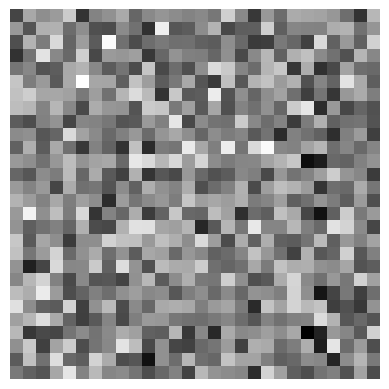

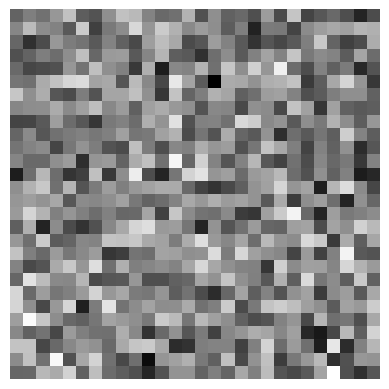

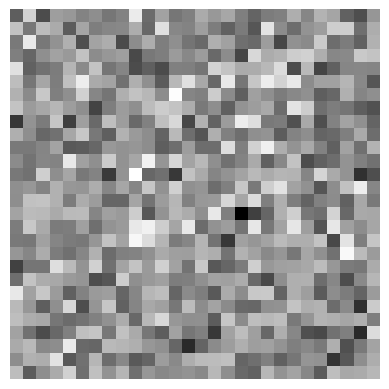

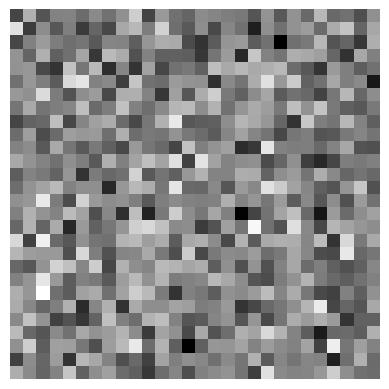

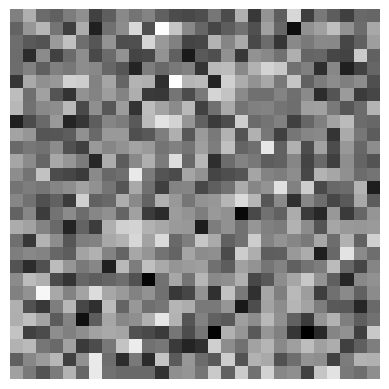

Epoch: 200


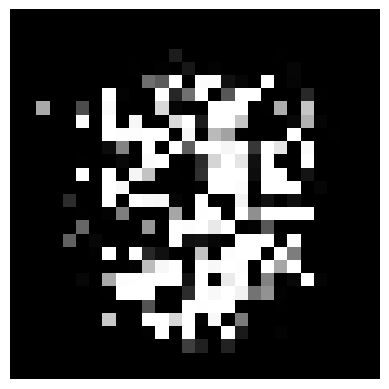

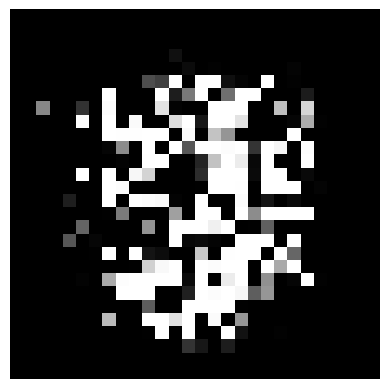

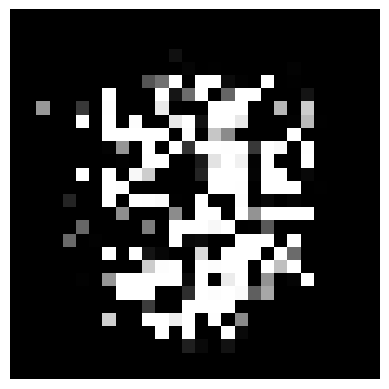

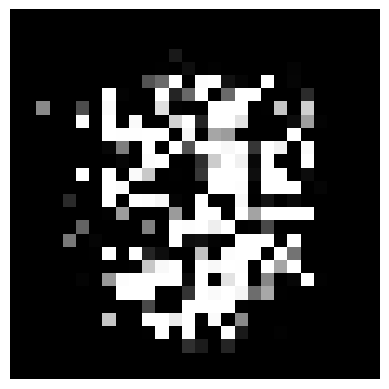

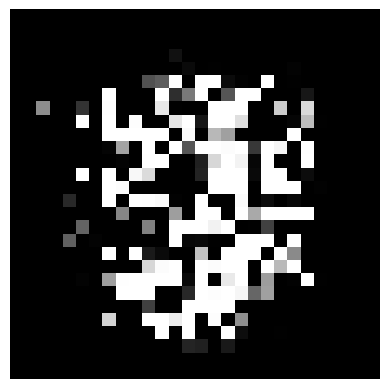

Epoch: 400


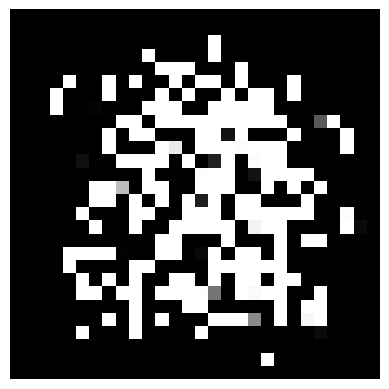

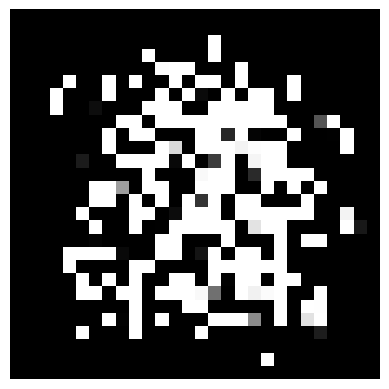

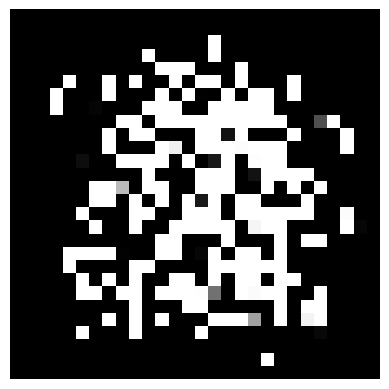

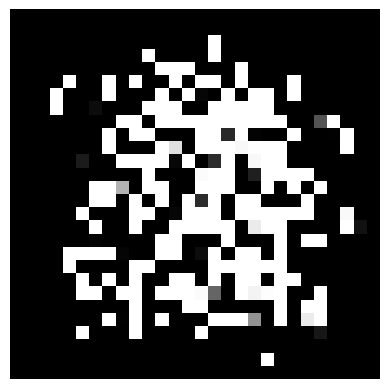

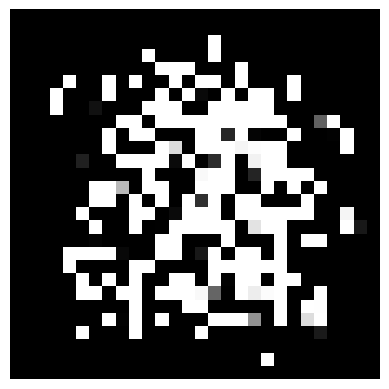

Epoch: 600


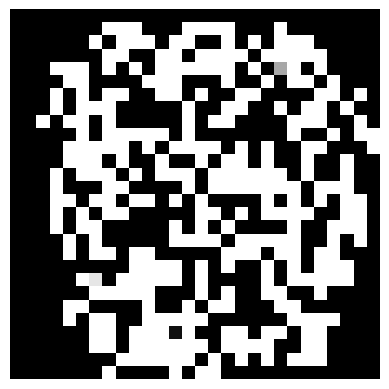

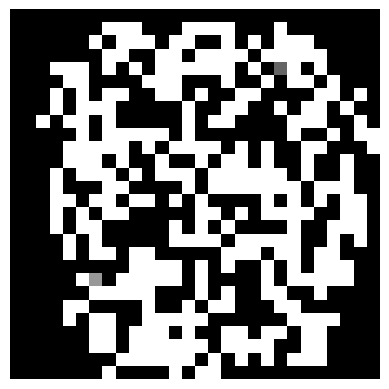

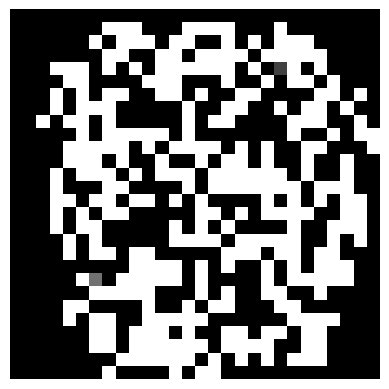

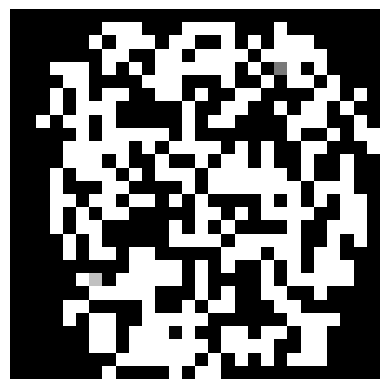

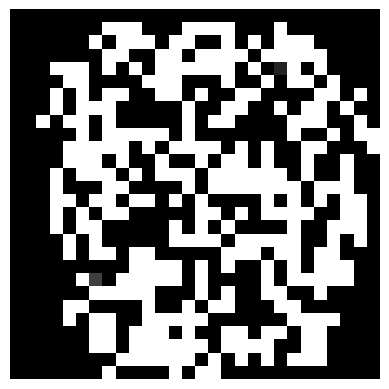

Epoch: 800


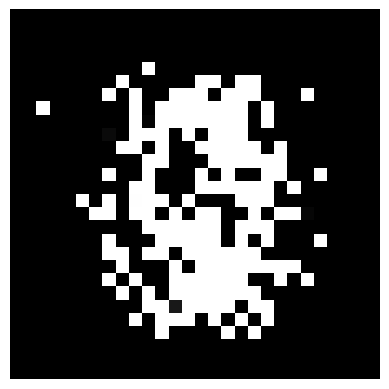

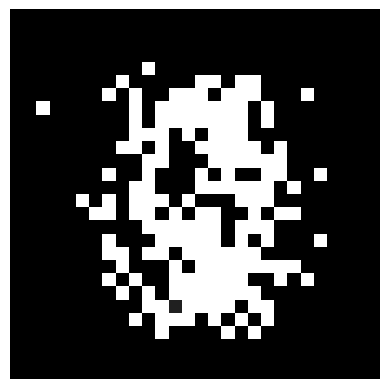

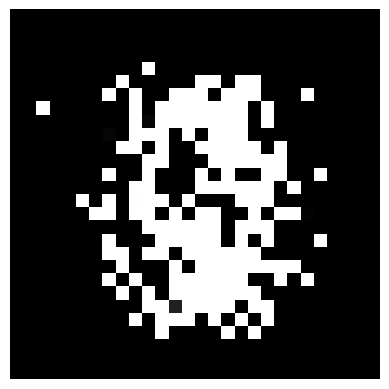

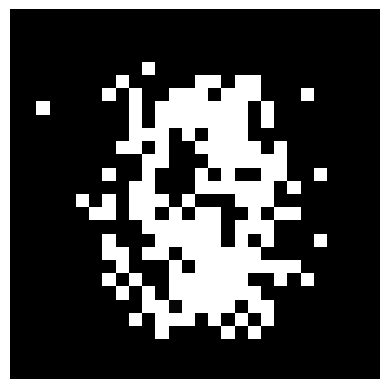

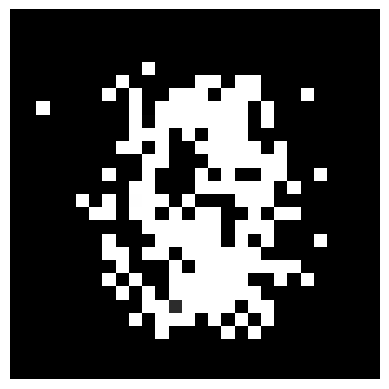

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

(X_train, _), _ = tf.keras.datasets.mnist.load_data()
X_train = X_train / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)

def build_generator():
    return tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(784, activation='sigmoid'),
        layers.Reshape((28,28,1))
    ])

def build_discriminator():
    return tf.keras.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

discriminator.trainable = False

z = layers.Input(shape=(100,))
img = generator(z)
valid = discriminator(img)

gan = tf.keras.Model(z, valid)
gan.compile(optimizer='adam', loss='binary_crossentropy')

epochs = 1000
batch_size = 32

for epoch in range(epochs):

    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    discriminator.trainable = False
    gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 200 == 0:
        print("Epoch:", epoch)

        sample_noise = np.random.normal(0,1,(5,100))
        generated = generator.predict(sample_noise, verbose=0)

        for i in range(5):
            plt.imshow(generated[i].reshape(28,28), cmap='gray')
            plt.axis('off')
            plt.show()

OBSERVATIONS


Initially generator produced random noise


After training, images started resembling digits


Quality improved with more epochs


Proper trainable control is necessary for GAN training

In [ ]:
!pip install nbstripout
!nbstripout week11-13.ipynb

Could not strip 'week11-13.ipynb': file not found


In [ ]:
from google.colab import files
files.upload()

Saving week11_13.ipynb to week11_13.ipynb


{'week11_13.ipynb': b'{\n  "nbformat": 4,\n  "nbformat_minor": 0,\n  "metadata": {\n    "colab": {\n      "provenance": []\n    },\n    "kernelspec": {\n      "name": "python3",\n      "display_name": "Python 3"\n    },\n    "language_info": {\n      "name": "python"\n    },\n    "widgets": {\n      "application/vnd.jupyter.widget-state+json": {\n        "fa4fe2b9387e402aa632cb62169ce6bc": {\n          "model_module": "@jupyter-widgets/controls",\n          "model_name": "HBoxModel",\n          "model_module_version": "1.5.0",\n          "state": {\n            "_dom_classes": [],\n            "_model_module": "@jupyter-widgets/controls",\n            "_model_module_version": "1.5.0",\n            "_model_name": "HBoxModel",\n            "_view_count": null,\n            "_view_module": "@jupyter-widgets/controls",\n            "_view_module_version": "1.5.0",\n            "_view_name": "HBoxView",\n            "box_style": "",\n            "children": [\n              "IPY_MODEL_648dc

In [ ]:
!nbstripout week11_13.ipynb